# Full Analysis — RBL-4 Week 8

**Purpose:** compute mutation score, paired statistical testing, effect size, and visualizations for the full experiment.

This notebook analyzes the provided full-run files only:

- `data/full_ground_truth.csv`
- `results/full_llm_output.csv`
- `results/full_gpt_selected.csv`
- `results/full_random_selected.csv`

No `by_group_selected` files are used in this notebook.

## Research Question

**RQ1:** Does GPT-4o-mini-based mutant selection achieve a higher mutation score than fixed-seed random selection under the same mutant budget?

## Pre-registered metric and test

- Metric: `Mutation Score = Killed / Selected`
- Pairing unit: `(project, version, class_name)`
- Test: Wilcoxon signed-rank test, one-sided
- Alternative hypothesis: `MS_GPT4o > MS_random`
- Effect size: matched-pairs rank-biserial correlation


In [1]:
from pathlib import Path
import sys
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "results" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIG_DIR:", FIG_DIR)


PROJECT_ROOT: /mnt/data/full_analysis_workspace
DATA_DIR: /mnt/data/full_analysis_workspace/data
RESULTS_DIR: /mnt/data/full_analysis_workspace/results
FIG_DIR: /mnt/data/full_analysis_workspace/results/figures


## 1. Load full-run files

In [2]:
ground_truth_path = DATA_DIR / "full_ground_truth.csv"
llm_output_path = RESULTS_DIR / "full_llm_output.csv"
gpt_selected_path = RESULTS_DIR / "full_gpt_selected.csv"
random_selected_path = RESULTS_DIR / "full_random_selected.csv"

required_files = [
    ground_truth_path,
    llm_output_path,
    gpt_selected_path,
    random_selected_path,
]

for p in required_files:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

ground_truth = pd.read_csv(ground_truth_path)
llm_output = pd.read_csv(llm_output_path)
gpt_selected = pd.read_csv(gpt_selected_path)
random_selected = pd.read_csv(random_selected_path)

print("ground_truth:", ground_truth.shape)
print("llm_output:", llm_output.shape)
print("gpt_selected:", gpt_selected.shape)
print("random_selected:", random_selected.shape)

display(ground_truth.head(3))
display(llm_output.head(3))


ground_truth: (50694, 20)
llm_output: (50694, 22)
gpt_selected: (5438, 24)
random_selected: (5438, 11)


,detected,status,numberOfTestsRun,sourceFile,mutatedClass,mutatedMethod,methodDescription,lineNumber,mutator,indexes,blocks,killingTest,description,project,version,target_mode,source_xml,local_index,killed,mutant_id
0,True,KILLED,1,StringUtils.java,org.apache.commons.lang3.StringUtils,abbreviate,(Ljava/lang/String;I)Ljava/lang/String;,6200,org.pitest.mutationtest.engine.gregor.mutators...,NaN,NaN,org.apache.commons.lang3.StringUtilsTest.testA...,"replaced return value with """" for org/apache/c...",Lang,7f,full,/kaggle/working/results_full20/pit_reports/Lan...,1,True,Lang_7f_full_1
1,True,KILLED,1,StringUtils.java,org.apache.commons.lang3.StringUtils,abbreviate,(Ljava/lang/String;II)Ljava/lang/String;,6242,org.pitest.mutationtest.engine.gregor.mutators...,NaN,NaN,org.apache.commons.lang3.StringUtilsTest.testA...,changed conditional boundary,Lang,7f,full,/kaggle/working/results_full20/pit_reports/Lan...,2,True,Lang_7f_full_2
2,True,KILLED,1,StringUtils.java,org.apache.commons.lang3.StringUtils,abbreviate,(Ljava/lang/String;II)Ljava/lang/String;,6245,org.pitest.mutationtest.engine.gregor.mutators...,NaN,NaN,org.apache.commons.lang3.StringUtilsTest.testA...,changed conditional boundary,Lang,7f,full,/kaggle/working/results_full20/pit_reports/Lan...,3,True,Lang_7f_full_3


,mutant_id,project,version,class_name,method_name,line_number,mutation_operator,original_code,mutated_code,surrounding_context,usefulness_score,short_reason,api_status,checkpoint_status,timestamp,model,prompt_tokens,completion_tokens,total_tokens,estimated_cost_usd,latency_seconds,rank
0,Lang_10f_full_6496,Lang,10f,org.apache.commons.lang3.time.FastDatePrinter,format,384,NegateConditionalsMutator,} else if (obj instanceof Long) {,PIT_MUTATION_DESCRIPTION: negated conditional,380: if (obj instanceof Date) {\r\n...,5,Negating conditionals can reveal logical flaws...,success,done,2026-07-05T12:26:17,gpt-4o-mini,1423,232,1655,0.0,3.500,1
1,Lang_10f_full_8329,Lang,10f,org.apache.commons.lang3.mutable.MutableInt,subtract,159,MathMutator,this.value -= operand;,PIT_MUTATION_DESCRIPTION: Replaced integer sub...,155: * @param operand the value to su...,5,Replacing subtraction with addition is a signi...,success,done,2026-07-05T12:50:07,gpt-4o-mini,1239,255,1494,0.0,3.937,2
2,Lang_10f_full_6102,Lang,10f,org.apache.commons.lang3.text.ExtendedMessageF...,equals,281,NegateConditionalsMutator,"if (ObjectUtils.notEqual(registry, rhs.registr...",PIT_MUTATION_DESCRIPTION: negated conditional,277: ExtendedMessageFormat rhs = (E...,5,Negating conditionals can reveal logical flaws...,success,done,2026-07-05T12:21:38,gpt-4o-mini,1199,234,1433,0.0,3.604,3


## 2. Sanity checks

This section checks whether the files are aligned by `mutant_id` and whether the selected mutants exist in the ground-truth table.


In [3]:
def require_columns(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise RuntimeError(f"{name} missing columns: {missing}")

require_columns(ground_truth, ["mutant_id", "killed"], "full_ground_truth.csv")
require_columns(llm_output, ["mutant_id", "project", "version", "class_name", "usefulness_score"], "full_llm_output.csv")
require_columns(gpt_selected, ["mutant_id", "project", "version", "class_name"], "full_gpt_selected.csv")
require_columns(random_selected, ["mutant_id", "project", "version", "class_name"], "full_random_selected.csv")

for name, df in [
    ("ground_truth", ground_truth),
    ("llm_output", llm_output),
    ("gpt_selected", gpt_selected),
    ("random_selected", random_selected),
]:
    print(f"{name} duplicate mutant_id:", df["mutant_id"].astype(str).duplicated().sum())

ground_truth_ids = set(ground_truth["mutant_id"].astype(str))
gpt_missing = set(gpt_selected["mutant_id"].astype(str)) - ground_truth_ids
random_missing = set(random_selected["mutant_id"].astype(str)) - ground_truth_ids

print("GPT selected not in ground truth:", len(gpt_missing))
print("Random selected not in ground truth:", len(random_missing))

if gpt_missing or random_missing:
    raise RuntimeError("Selected mutants are not fully covered by ground truth.")


ground_truth duplicate mutant_id: 0
llm_output duplicate mutant_id: 0
gpt_selected duplicate mutant_id: 0
random_selected duplicate mutant_id: 0
GPT selected not in ground truth: 0
Random selected not in ground truth: 0


## 3. Dataset and selection coverage

In [4]:
print("Ground truth mutant count by project:")
display(ground_truth["project"].value_counts().rename("mutants").to_frame())

print("LLM output count by project:")
display(llm_output["project"].value_counts().rename("mutants").to_frame())

print("GPT selected count by project:")
display(gpt_selected["project"].value_counts().rename("selected").to_frame())

print("Random selected count by project:")
display(random_selected["project"].value_counts().rename("selected").to_frame())

coverage = pd.DataFrame({
    "ground_truth_pool": ground_truth["project"].value_counts(),
    "llm_output_pool": llm_output["project"].value_counts(),
    "gpt_selected": gpt_selected["project"].value_counts(),
    "random_selected": random_selected["project"].value_counts(),
}).fillna(0).astype(int)

coverage["gpt_selected_pct_of_pool"] = coverage["gpt_selected"] / coverage["ground_truth_pool"] * 100
coverage["random_selected_pct_of_pool"] = coverage["random_selected"] / coverage["ground_truth_pool"] * 100

display(coverage)
coverage.to_csv(RESULTS_DIR / "full_coverage_by_project.csv", encoding="utf-8")


Ground truth mutant count by project:


,mutants
project,
Lang,47727
Math,2967


LLM output count by project:


,mutants
project,
Lang,47727
Math,2967


GPT selected count by project:


,selected
project,
Lang,5135
Math,303


Random selected count by project:


,selected
project,
Lang,5135
Math,303


,ground_truth_pool,llm_output_pool,gpt_selected,random_selected,gpt_selected_pct_of_pool,random_selected_pct_of_pool
project,,,,,,
Lang,47727,47727,5135,5135,10.759109,10.759109
Math,2967,2967,303,303,10.212336,10.212336


## 4. GPT usefulness score distribution

This is a descriptive check only. `usefulness_score` is the LLM ranking score, not the mutation score.


,count
usefulness_score,
1,343
2,4489
3,14116
4,18732
5,13014


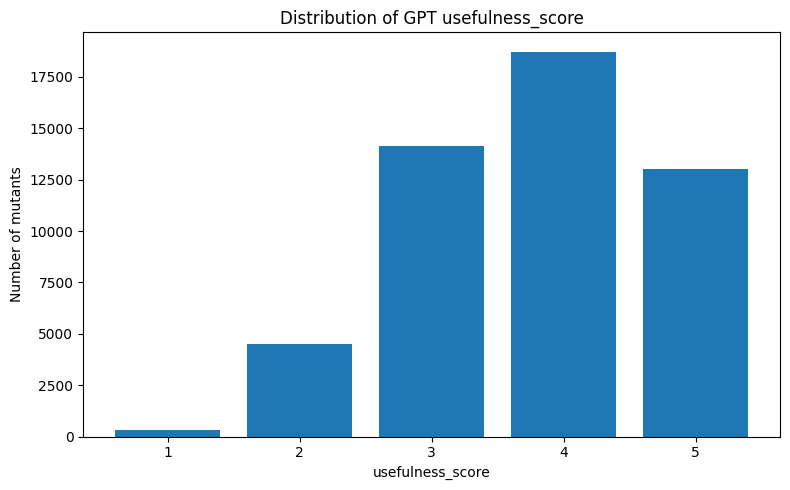

In [5]:
score_counts = llm_output["usefulness_score"].value_counts().sort_index()
display(score_counts.rename("count").to_frame())

plt.figure(figsize=(8, 5))
plt.bar(score_counts.index.astype(str), score_counts.values)
plt.title("Distribution of GPT usefulness_score")
plt.xlabel("usefulness_score")
plt.ylabel("Number of mutants")
plt.tight_layout()
plt.savefig(FIG_DIR / "full_usefulness_score_distribution.png", dpi=200)
plt.show()


## 5. Merge selected mutants with ground truth

In [6]:
def to_bool_killed(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.lower().isin(["true", "1", "yes", "killed"])

ground_truth = ground_truth.copy()
ground_truth["mutant_id"] = ground_truth["mutant_id"].astype(str)
ground_truth["killed_bool"] = to_bool_killed(ground_truth["killed"])

def load_selected_with_killed(selected: pd.DataFrame, label: str) -> pd.DataFrame:
    selected = selected.copy()
    selected["mutant_id"] = selected["mutant_id"].astype(str)
    merged = selected.merge(
        ground_truth[["mutant_id", "killed_bool"]],
        on="mutant_id",
        how="left",
    )
    missing = int(merged["killed_bool"].isna().sum())
    if missing:
        raise ValueError(f"{label}: {missing} selected mutant_id not found in full_ground_truth.csv")
    merged["killed"] = merged["killed_bool"].astype(bool)
    merged = merged.drop(columns=["killed_bool"])
    return merged

gpt_eval = load_selected_with_killed(gpt_selected, "GPT")
random_eval = load_selected_with_killed(random_selected, "Random")

print("GPT selected:", len(gpt_eval), "killed:", int(gpt_eval["killed"].sum()))
print("Random selected:", len(random_eval), "killed:", int(random_eval["killed"].sum()))


GPT selected: 5438 killed: 4791
Random selected: 5438 killed: 4539


## 6. Overall selected-mutant mutation score

This computes the direct selected-mutant-level mutation score:

```text
MS = killed selected mutants / total selected mutants
```


,strategy,selected,killed,mutation_score
0,GPT4o-mini,5438,4791,0.881022
1,Random fixed-seed,5438,4539,0.834682


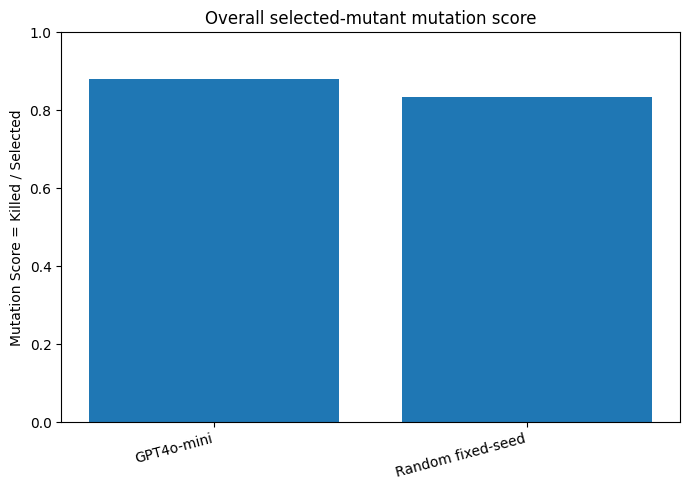

In [7]:
overall_rows = []

for label, df in [("GPT4o-mini", gpt_eval), ("Random fixed-seed", random_eval)]:
    overall_rows.append({
        "strategy": label,
        "selected": len(df),
        "killed": int(df["killed"].sum()),
        "mutation_score": float(df["killed"].mean()),
    })

overall_ms = pd.DataFrame(overall_rows)
display(overall_ms)

overall_ms.to_csv(RESULTS_DIR / "full_overall_mutation_score.csv", index=False, encoding="utf-8")

plt.figure(figsize=(7, 5))
plt.bar(overall_ms["strategy"], overall_ms["mutation_score"])
plt.title("Overall selected-mutant mutation score")
plt.ylabel("Mutation Score = Killed / Selected")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "full_overall_mutation_score.png", dpi=200)
plt.show()


## 7. Paired group-level mutation score

The statistical test is performed on paired `(project, version, class_name)` groups, following the team protocol.

For each group and each selection strategy:

```text
group MS = killed selected mutants in group / selected mutants in group
```


In [8]:
GROUP_COLS = ["project", "version", "class_name"]

def group_mutation_score(df: pd.DataFrame, label: str) -> pd.DataFrame:
    g = df.groupby(GROUP_COLS, dropna=False).agg(
        selected=("mutant_id", "count"),
        killed=("killed", "sum"),
    )
    g[f"ms_{label}"] = g["killed"] / g["selected"]
    g = g.rename(columns={
        "selected": f"selected_{label}",
        "killed": f"killed_{label}",
    })
    return g

ms_gpt = group_mutation_score(gpt_eval, "gpt")
ms_random = group_mutation_score(random_eval, "random")

paired = ms_gpt.join(ms_random, how="inner").reset_index()
paired["diff_gpt_minus_random"] = paired["ms_gpt"] - paired["ms_random"]

paired_path = RESULTS_DIR / "paired_mutation_scores.csv"
paired.to_csv(paired_path, index=False, encoding="utf-8")

print("Paired groups:", len(paired))
print("Saved:", paired_path)
display(paired.head())
display(paired["project"].value_counts().rename("paired_groups").to_frame())


Paired groups: 757
Saved: /mnt/data/full_analysis_workspace/results/paired_mutation_scores.csv


,project,version,class_name,selected_gpt,killed_gpt,ms_gpt,selected_random,killed_random,ms_random,diff_gpt_minus_random
0,Lang,10f,org.apache.commons.lang3.AnnotationUtils,11,10,0.909091,11,9,0.818182,0.090909
1,Lang,10f,org.apache.commons.lang3.AnnotationUtils$1,2,2,1.000000,2,0,0.000000,1.000000
2,Lang,10f,org.apache.commons.lang3.ArrayUtils,119,117,0.983193,119,109,0.915966,0.067227
3,Lang,10f,org.apache.commons.lang3.BitField,4,2,0.500000,4,4,1.000000,-0.500000
4,Lang,10f,org.apache.commons.lang3.BooleanUtils,22,22,1.000000,22,22,1.000000,0.000000


,paired_groups
project,
Lang,739
Math,18


## 8. Wilcoxon signed-rank test and rank-biserial effect size

In [9]:
N_GROUP_MIN = 10

def rank_biserial_from_wilcoxon(diff: np.ndarray) -> float:
    nz = diff[diff != 0]
    n = len(nz)
    if n == 0:
        return float("nan")
    ranks = pd.Series(np.abs(nz)).rank(method="average").to_numpy()
    w_pos = ranks[nz > 0].sum()
    w_neg = ranks[nz < 0].sum()
    total = n * (n + 1) / 2
    return float((w_pos - w_neg) / total)

def analyze_subset(paired_subset: pd.DataFrame, label: str) -> dict:
    diff = paired_subset["diff_gpt_minus_random"].to_numpy()
    n_pairs = len(diff)
    n_nonzero = int((diff != 0).sum())

    row = {
        "subset": label,
        "n_group": n_pairs,
        "n_pairs": n_pairs,
        "n_nonzero_pairs": n_nonzero,
        "mean_ms_gpt": float(paired_subset["ms_gpt"].mean()) if n_pairs else float("nan"),
        "mean_ms_random": float(paired_subset["ms_random"].mean()) if n_pairs else float("nan"),
        "median_ms_gpt": float(paired_subset["ms_gpt"].median()) if n_pairs else float("nan"),
        "median_ms_random": float(paired_subset["ms_random"].median()) if n_pairs else float("nan"),
        "win_gpt": int((diff > 0).sum()),
        "win_random": int((diff < 0).sum()),
        "tie": int((diff == 0).sum()),
        "p_value": float("nan"),
        "effect_size_rank_biserial": float("nan"),
        "ran_test": False,
        "reason_skipped": "",
    }

    if n_pairs < N_GROUP_MIN:
        row["reason_skipped"] = "n_group < 10: descriptive only"
        return row

    if n_nonzero == 0:
        row["reason_skipped"] = "all paired differences are zero"
        return row

    stat, p_value = wilcoxon(diff, alternative="greater", zero_method="wilcox")
    row["p_value"] = float(p_value)
    row["effect_size_rank_biserial"] = rank_biserial_from_wilcoxon(diff)
    row["ran_test"] = True
    return row

rows = [analyze_subset(paired, "RQ1_pooled_all_projects")]

for project in sorted(paired["project"].dropna().unique()):
    subset = paired[paired["project"] == project]
    rows.append(analyze_subset(subset, f"RQ1_subgroup_{project}"))

summary = pd.DataFrame(rows)

ordered_cols = [
    "subset", "n_group", "n_pairs", "n_nonzero_pairs",
    "mean_ms_gpt", "mean_ms_random", "median_ms_gpt", "median_ms_random",
    "win_gpt", "win_random", "tie",
    "p_value", "effect_size_rank_biserial", "ran_test", "reason_skipped",
]

summary = summary[ordered_cols]
summary_path = RESULTS_DIR / "summary.csv"
summary.to_csv(summary_path, index=False, encoding="utf-8")

print("Saved:", summary_path)
display(summary)


Saved: /mnt/data/full_analysis_workspace/results/summary.csv


,subset,n_group,n_pairs,n_nonzero_pairs,mean_ms_gpt,mean_ms_random,median_ms_gpt,median_ms_random,win_gpt,win_random,tie,p_value,effect_size_rank_biserial,ran_test,reason_skipped
0,RQ1_pooled_all_projects,757,757,256,0.834268,0.779154,1.000000,1.000000,180,76,501,1.734309e-09,0.425492,True,
1,RQ1_subgroup_Lang,739,739,245,0.834279,0.777896,1.000000,1.000000,173,72,494,1.633260e-09,0.435606,True,
2,RQ1_subgroup_Math,18,18,11,0.833804,0.830807,0.904167,0.861905,7,4,7,3.444690e-01,0.136364,True,


## 9. Visualization of paired mutation scores

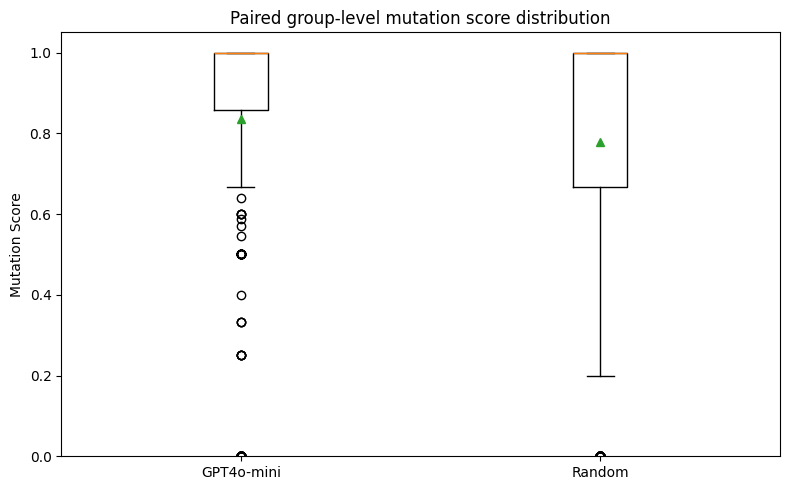

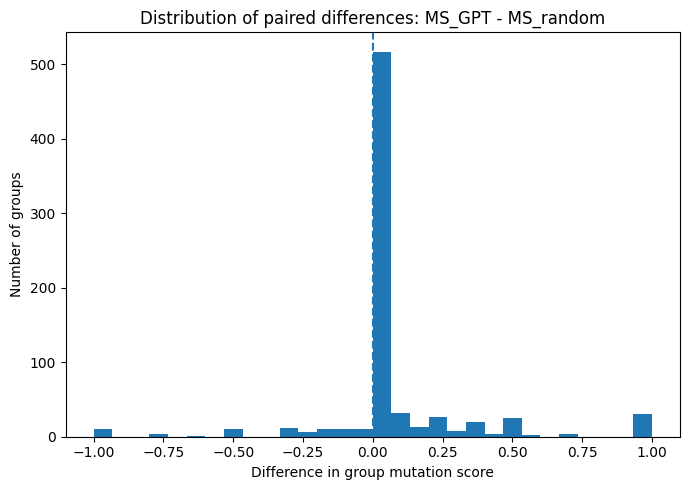

,project,n_group,mean_ms_gpt,mean_ms_random,mean_diff
0,Lang,739,0.834279,0.777896,0.056384
1,Math,18,0.833804,0.830807,0.002997


In [10]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [paired["ms_gpt"], paired["ms_random"]],
    labels=["GPT4o-mini", "Random"],
    showmeans=True,
)
plt.title("Paired group-level mutation score distribution")
plt.ylabel("Mutation Score")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / "full_group_ms_boxplot.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(paired["diff_gpt_minus_random"], bins=30)
plt.axvline(0, linestyle="--")
plt.title("Distribution of paired differences: MS_GPT - MS_random")
plt.xlabel("Difference in group mutation score")
plt.ylabel("Number of groups")
plt.tight_layout()
plt.savefig(FIG_DIR / "full_group_ms_difference_histogram.png", dpi=200)
plt.show()

project_summary = paired.groupby("project").agg(
    n_group=("class_name", "count"),
    mean_ms_gpt=("ms_gpt", "mean"),
    mean_ms_random=("ms_random", "mean"),
    mean_diff=("diff_gpt_minus_random", "mean"),
).reset_index()

display(project_summary)
project_summary.to_csv(RESULTS_DIR / "full_project_summary.csv", index=False, encoding="utf-8")


## 10. Conclusion template

Use this section as the Week 8 conclusion for the full run.


In [11]:
def fmt_p(x):
    if pd.isna(x):
        return "NA"
    if x < 0.001:
        return f"{x:.2e}"
    return f"{x:.4f}"

pooled = summary[summary["subset"] == "RQ1_pooled_all_projects"].iloc[0]

alpha = 0.05
supports_h1 = pooled["ran_test"] and pooled["p_value"] < alpha and pooled["mean_ms_gpt"] > pooled["mean_ms_random"]

conclusion = {
    "pooled_mean_ms_gpt": pooled["mean_ms_gpt"],
    "pooled_mean_ms_random": pooled["mean_ms_random"],
    "p_value": pooled["p_value"],
    "effect_size_rank_biserial": pooled["effect_size_rank_biserial"],
    "supports_H1": bool(supports_h1),
}

print(json.dumps(conclusion, indent=2))

if supports_h1:
    print(
        f"Conclusion: GPT4o-mini selection achieved a higher paired group-level mutation score "
        f"than the fixed-seed random baseline "
        f"(mean MS {pooled['mean_ms_gpt']:.4f} vs {pooled['mean_ms_random']:.4f}, "
        f"one-sided Wilcoxon p={fmt_p(pooled['p_value'])}, "
        f"rank-biserial r={pooled['effect_size_rank_biserial']:.3f}). "
        f"Therefore, the result supports H1 for RQ1."
    )
else:
    print(
        f"Conclusion: The full-run analysis does not provide sufficient evidence to support H1 "
        f"under the pre-registered one-sided Wilcoxon test "
        f"(mean MS {pooled['mean_ms_gpt']:.4f} vs {pooled['mean_ms_random']:.4f}, "
        f"p={fmt_p(pooled['p_value'])})."
    )

print("\nSubgroup notes:")
for _, row in summary[summary["subset"] != "RQ1_pooled_all_projects"].iterrows():
    if row["ran_test"]:
        verdict = "supports H1" if row["p_value"] < alpha and row["mean_ms_gpt"] > row["mean_ms_random"] else "does not support H1"
        print(
            f"- {row['subset']}: mean MS {row['mean_ms_gpt']:.4f} vs {row['mean_ms_random']:.4f}, "
            f"p={fmt_p(row['p_value'])}, r={row['effect_size_rank_biserial']:.3f} → {verdict}."
        )
    else:
        print(f"- {row['subset']}: descriptive only ({row['reason_skipped']}).")


{
  "pooled_mean_ms_gpt": 0.8342681130317898,
  "pooled_mean_ms_random": 0.7791537387103532,
  "p_value": 1.734308992764016e-09,
  "effect_size_rank_biserial": 0.4254924610894942,
  "supports_H1": true
}
Conclusion: GPT4o-mini selection achieved a higher paired group-level mutation score than the fixed-seed random baseline (mean MS 0.8343 vs 0.7792, one-sided Wilcoxon p=1.73e-09, rank-biserial r=0.425). Therefore, the result supports H1 for RQ1.

Subgroup notes:
- RQ1_subgroup_Lang: mean MS 0.8343 vs 0.7779, p=1.63e-09, r=0.436 → supports H1.
- RQ1_subgroup_Math: mean MS 0.8338 vs 0.8308, p=0.3445, r=0.136 → does not support H1.


## 11. Generated outputs

This notebook writes:

- `results/summary.csv`
- `results/paired_mutation_scores.csv`
- `results/full_overall_mutation_score.csv`
- `results/full_coverage_by_project.csv`
- `results/full_project_summary.csv`
- `results/figures/full_usefulness_score_distribution.png`
- `results/figures/full_overall_mutation_score.png`
- `results/figures/full_group_ms_boxplot.png`
- `results/figures/full_group_ms_difference_histogram.png`
